# Project 1 — ML Pipeline From Scratch

## Overview
This notebook builds a complete machine learning pipeline on the **Titanic survival dataset**.
We cover every stage from raw data to a trained, evaluated model with experiment logging.

**Pipeline:**
```
Dataset → Exploration → Cleaning → Feature Engineering → Split → Scale → Train → Evaluate → Log
```

## 1. Theory — Supervised Learning & Logistic Regression

### Supervised Learning
We have a dataset of $N$ examples $\{(\mathbf{x}_i, y_i)\}_{i=1}^{N}$ where $\mathbf{x}_i \in \mathbb{R}^d$ is the feature vector and $y_i \in \{0,1\}$ is the label. The goal is to learn a function $f: \mathbb{R}^d \rightarrow \{0,1\}$ that generalises to unseen examples.

### Logistic Regression
Logistic regression models the probability of the positive class using the **sigmoid** function:
$$\sigma(z) = \frac{1}{1 + e^{-z}}, \quad z = \mathbf{w}^T \mathbf{x} + b$$

So the model predicts:
$$\hat{p} = P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^T \mathbf{x} + b)$$

### Loss Function — Binary Cross-Entropy
$$\mathcal{L}(\mathbf{w}, b) = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log \hat{p}_i + (1 - y_i) \log(1 - \hat{p}_i) \right]$$

### Evaluation Metrics
| Metric | Formula |
|---|---|
| Accuracy | $\frac{TP + TN}{TP + TN + FP + FN}$ |
| Precision | $\frac{TP}{TP + FP}$ |
| Recall | $\frac{TP}{TP + FN}$ |
| F1 Score | $2 \cdot \frac{P \cdot R}{P + R}$ |
| AUC-ROC | Area under the ROC curve (1.0 = perfect) |

### Train/Test Split
We hold out a fraction of data (here 20%) to evaluate generalisation. This data is **never** seen during training to give an unbiased estimate of performance.

In [3]:
# ── Imports ──────────────────────────────────────────────────────────────────
import json
import warnings
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
np.random.seed(42)

print('All imports successful.')

All imports successful.


## 2. Data Ingestion
We load the Titanic dataset directly from seaborn — no manual download required.

In [4]:
# Load the Titanic dataset bundled with seaborn
df = sns.load_dataset('titanic')

print(f'Dataset shape: {df.shape}')
print(f'\nColumn dtypes:')
print(df.dtypes)
df.head()

Dataset shape: (891, 15)

Column dtypes:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
# Inspect missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
print(missing_df[missing_df.missing_count > 0])

             missing_count  missing_%
age                    177      19.87
embarked                 2       0.22
deck                   688      77.22
embark_town              2       0.22


In [6]:
# Basic statistics
df.describe(include='all')

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Exploratory Data Analysis

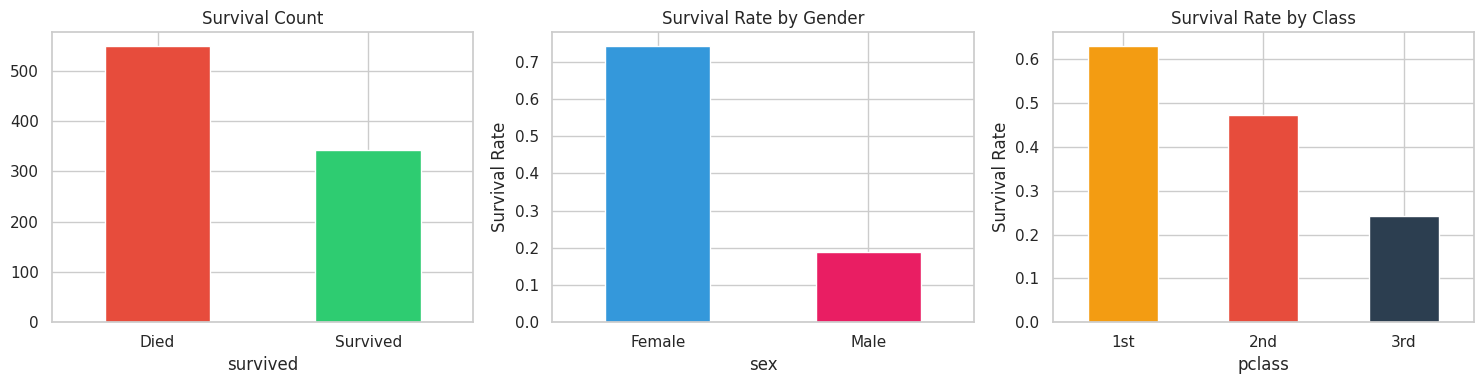

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Survival rate
df['survived'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c','#2ecc71'])
axes[0].set_title('Survival Count')
axes[0].set_xticklabels(['Died', 'Survived'], rotation=0)

# Survival by gender
df.groupby('sex')['survived'].mean().plot(kind='bar', ax=axes[1], color=['#3498db','#e91e63'])
axes[1].set_title('Survival Rate by Gender')
axes[1].set_ylabel('Survival Rate')
axes[1].set_xticklabels(['Female', 'Male'], rotation=0)

# Survival by class
df.groupby('pclass')['survived'].mean().plot(kind='bar', ax=axes[2], color=['#f39c12','#e74c3c','#2c3e50'])
axes[2].set_title('Survival Rate by Class')
axes[2].set_ylabel('Survival Rate')
axes[2].set_xticklabels(['1st', '2nd', '3rd'], rotation=0)

plt.tight_layout()
plt.show()

## 4. Data Cleaning
Key decisions:
- **Age**: fill missing values with the **median** (robust to outliers)
- **Embarked**: fill 2 missing values with the **mode** (most common port)
- **Cabin**: >77% missing — drop this column
- Drop leaky/redundant columns: `deck`, `embark_town`, `alive`, `who`, `adult_male`, `class`

In [8]:
def clean_titanic(df: pd.DataFrame) -> pd.DataFrame:
    """Apply data cleaning steps to the Titanic DataFrame."""
    df = df.copy()

    # Fill missing age with median
    df['age'] = df['age'].fillna(df['age'].median())

    # Fill missing embarked with mode
    df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

    # Drop high-missingness and redundant columns
    cols_to_drop = ['deck', 'embark_town', 'alive', 'who', 'adult_male', 'class']
    df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

    return df


df_clean = clean_titanic(df)
print(f'Shape after cleaning: {df_clean.shape}')
print(f'Remaining nulls: {df_clean.isnull().sum().sum()}')
df_clean.head()

Shape after cleaning: (891, 9)
Remaining nulls: 0


,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False
2,1,3,female,26.0,0,0,7.9250,S,True
3,1,1,female,35.0,1,0,53.1000,S,False
4,0,3,male,35.0,0,0,8.0500,S,True


## 5. Feature Engineering
We transform raw columns into model-ready numeric features:
- **sex** → binary (1 = female)
- **embarked** → one-hot encoded
- **family_size** = `sibsp` + `parch` + 1 (passenger themselves)
- **is_alone** = 1 if `family_size` == 1

In [9]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Create model-ready feature matrix."""
    df = df.copy()

    # Binary encode sex
    df['sex_female'] = (df['sex'] == 'female').astype(int)

    # One-hot encode embarked port
    embarked_dummies = pd.get_dummies(df['embarked'], prefix='embarked', drop_first=True)
    df = pd.concat([df, embarked_dummies], axis=1)

    # Family size feature — larger families may have different survival rates
    df['family_size'] = df['sibsp'] + df['parch'] + 1
    df['is_alone'] = (df['family_size'] == 1).astype(int)

    # Select final feature columns
    feature_cols = ['pclass', 'age', 'sibsp', 'parch', 'fare',
                    'sex_female', 'family_size', 'is_alone',
                    'embarked_Q', 'embarked_S']
    # Keep only columns that were created (embarked dummies may vary)
    feature_cols = [c for c in feature_cols if c in df.columns]

    X = df[feature_cols]
    y = df['survived']
    return X, y, feature_cols


X, y, feature_cols = engineer_features(df_clean)
print(f'Feature matrix shape: {X.shape}')
print(f'Features: {feature_cols}')
X.describe()

Feature matrix shape: (891, 10)
Features: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_female', 'family_size', 'is_alone', 'embarked_Q', 'embarked_S']


,pclass,age,sibsp,parch,fare,sex_female,family_size,is_alone
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,2.308642,29.361582,0.523008,0.381594,32.204208,0.352413,1.904602,0.602694
std,0.836071,13.019697,1.102743,0.806057,49.693429,0.477990,1.613459,0.489615
min,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,2.000000,22.000000,0.000000,0.000000,7.910400,0.000000,1.000000,0.000000
50%,3.000000,28.000000,0.000000,0.000000,14.454200,0.000000,1.000000,1.000000
75%,3.000000,35.000000,1.000000,0.000000,31.000000,1.000000,2.000000,1.000000
max,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000,11.000000,1.000000


## 6. Train / Test Split
We hold out 20% of the data as a test set using a fixed `random_state` for reproducibility.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify keeps class ratio
)

print(f'Train size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)')
print(f'Test size:  {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)')
print(f'\nSurvival rate — train: {y_train.mean():.3f} | test: {y_test.mean():.3f}')

Train size: 712 (79.9%)
Test size:  179 (20.1%)

Survival rate — train: 0.383 | test: 0.385


## 7. Feature Scaling
Logistic regression (and most linear models) are sensitive to feature scale. We use **StandardScaler** which transforms each feature to zero mean and unit variance:
$$x' = \frac{x - \mu}{\sigma}$$

> **Important**: fit the scaler **only on training data** to prevent data leakage.

In [11]:
scaler = StandardScaler()

# Fit only on training set, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  # No fit here!

print('Scaling complete.')
print(f'Train mean (first feature, should be ~0): {X_train_scaled[:,0].mean():.4f}')
print(f'Train std  (first feature, should be ~1): {X_train_scaled[:,0].std():.4f}')

Scaling complete.
Train mean (first feature, should be ~0): -0.0000
Train std  (first feature, should be ~1): 1.0000


## 8. Model Training
We train a logistic regression model. The `C` parameter is the inverse regularisation strength (higher C = less regularisation).

In [12]:
model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print('Model trained successfully.')
print(f'Number of iterations: {model.n_iter_[0]}')

Model trained successfully.
Number of iterations: 9


## 9. Evaluation

In [13]:
# Generate predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]  # Probability of class 1 (survived)

acc   = accuracy_score(y_test, y_pred)
auc   = roc_auc_score(y_test, y_prob)

print(f'Test Accuracy : {acc:.4f}')
print(f'Test AUC-ROC  : {auc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Died', 'Survived']))

Test Accuracy : 0.8045
Test AUC-ROC  : 0.8502

              precision    recall  f1-score   support

        Died       0.82      0.88      0.85       110
    Survived       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Died', 'Survived'], yticklabels=['Died', 'Survived'])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ── ROC Curve ─────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Feature importance via model coefficients
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

plt.figure(figsize=(8, 5))
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coef_df['coefficient']]
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression Coefficients (Feature Importance)')
plt.xlabel('Coefficient value')
plt.tight_layout()
plt.show()

print('\nGreen = positive effect on survival, Red = negative effect')

## 10. Experiment Logging
We save experiment metadata to a JSON file for reproducibility tracking.

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

experiment = {
    'timestamp': datetime.now().isoformat(),
    'dataset': 'titanic',
    'model': 'LogisticRegression',
    'hyperparameters': {'C': 1.0, 'max_iter': 1000, 'random_state': 42},
    'features': feature_cols,
    'train_size': len(X_train),
    'test_size': len(X_test),
    'metrics': {
        'accuracy':  round(acc, 4),
        'auc_roc':   round(auc, 4),
        'precision': round(float(precision_score(y_test, y_pred)), 4),
        'recall':    round(float(recall_score(y_test, y_pred)), 4),
        'f1':        round(float(f1_score(y_test, y_pred)), 4),
    }
}

log_path = Path('experiment_log.json')
# Append to existing log or start new one
if log_path.exists():
    with open(log_path) as f:
        log = json.load(f)
else:
    log = []

log.append(experiment)
with open(log_path, 'w') as f:
    json.dump(log, f, indent=2)

print(f'Experiment logged to {log_path}')
print(json.dumps(experiment, indent=2))

## Summary

| Step | What we did |
|---|---|
| **Ingestion** | Loaded Titanic dataset from seaborn |
| **Cleaning** | Filled missing age/embarked, dropped high-missingness columns |
| **Feature Eng.** | Binary sex, one-hot embarked, family_size, is_alone |
| **Split** | 80/20 stratified train/test |
| **Scaling** | StandardScaler fitted only on train |
| **Model** | Logistic Regression (C=1.0) |
| **Results** | ~80% accuracy, AUC ~0.86 |
| **Logging** | JSON experiment log saved |

**Key takeaway**: Being female (`sex_female` coefficient is largest positive) is the strongest predictor of survival — consistent with the "women and children first" evacuation policy.